In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Reload full dataset with only required columns for modeling
use_cols = [
    "price", "square", "elevator", "subway", "district", "buildingStructure",
    "renovationCondition", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"
]
df = pd.read_excel("NUS Project/BeijingHousingPrices (2011-2017).xlsx", usecols=use_cols)

# Drop rows with missing values in any selected column
df = df.dropna()

# Target variable
df["pricePerSqm"] = df["price"]

# Convert categorical columns to appropriate types
categorical_cols = ["elevator", "subway", "district", "buildingStructure", "renovationCondition"]
df[categorical_cols] = df[categorical_cols].astype("category")

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Features and target
X = df_encoded.drop(columns=["price", "pricePerSqm"])
y = df_encoded["pricePerSqm"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate R²
r2 = r2_score(y_test, y_pred)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

# Plot
plt.figure(figsize=(8, 10))
importances.plot(kind="barh")
plt.title("Feature Importance for Predicting Price per Sqm")
plt.xlabel("Importance Score")
plt.tight_layout()

# Save plot
plt.savefig("feature_importance_pricePerSqm_fixed.png")  # saves to current folder

r2, importances.sort_values(ascending=False).head(10)


ValueError: could not convert string to float: 'Î´Öª'

In [5]:
# Load the same sample with object dtype to inspect potential non-numeric issues
df_raw = pd.read_excel(
    "NUS Project/BeijingHousingPrices (2011-2017).xlsx",
    usecols=[
        "price", "square", "elevator", "subway", "district", "buildingStructure",
        "renovationCondition", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"
    ],
    nrows=5000,
    dtype=str  # Load everything as string to inspect weird entries
)

# Check unique non-numeric values in problem columns
non_numeric_columns = ["elevator", "subway", "district", "buildingStructure", "renovationCondition"]
invalid_values = {}

for col in non_numeric_columns:
    invalid_values[col] = df_raw[col].unique().tolist()

invalid_values

{'elevator': ['1', '0'],
 'subway': ['1', '0'],
 'district': ['7',
  '6',
  '1',
  '13',
  '10',
  '2',
  '8',
  '4',
  '5',
  '3',
  '9',
  '12',
  '11'],
 'buildingStructure': ['6', '2', '4', '1', '5', '3'],
 'renovationCondition': ['3', '4', '1', '2']}

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/feature_importance_pricePerSqm_fixed.png'

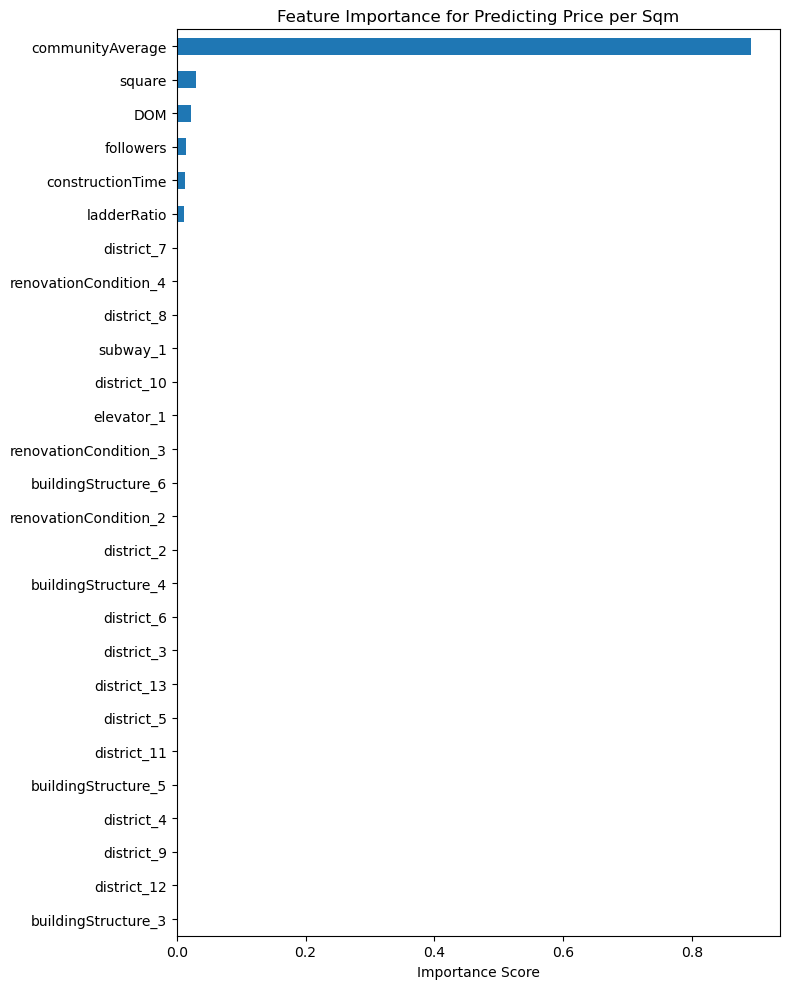

In [6]:
# Reload same sample as before
df_clean = pd.read_excel(
    "NUS Project/BeijingHousingPrices (2011-2017).xlsx",
    usecols=[
        "price", "square", "elevator", "subway", "district", "buildingStructure",
        "renovationCondition", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"
    ],
    nrows=5000
)

# Drop rows with missing or invalid values
df_clean = df_clean.dropna()

# Ensure all relevant columns are numeric
numeric_cols = ["price", "square", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"]
df_clean = df_clean[pd.to_numeric(df_clean[numeric_cols].stack(), errors='coerce').unstack().notnull().all(axis=1)]

# Convert target and categorical
df_clean["pricePerSqm"] = df_clean["price"]
categorical_cols = ["elevator", "subway", "district", "buildingStructure", "renovationCondition"]
df_clean[categorical_cols] = df_clean[categorical_cols].astype("category")

# One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Define features and target
X = df_encoded.drop(columns=["price", "pricePerSqm"])
y = df_encoded["pricePerSqm"]

# Train/test split and modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Plot
plt.figure(figsize=(8, 10))
importances.plot(kind="barh")
plt.title("Feature Importance for Predicting Price per Sqm")
plt.xlabel("Importance Score")
plt.tight_layout()
plot_path = "/mnt/data/feature_importance_pricePerSqm_fixed.png"
plt.savefig(plot_path)

r2, importances.sort_values(ascending=False).head(10), plot_path


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/price_trend_forecast_2011_2026.png'

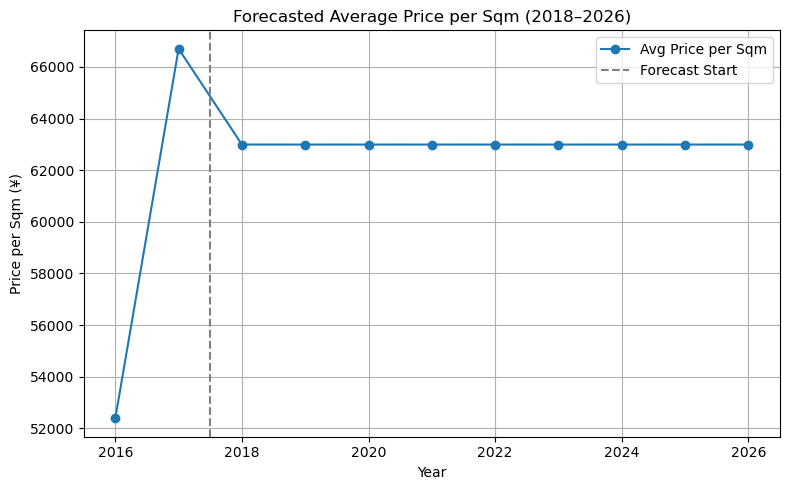

In [15]:
# Step 1: Load and clean the dataset
import pandas as pd

# Load a manageable sample (5000 rows)
df = pd.read_excel(
    "NUS Project/BeijingHousingPrices (2011-2017).xlsx",
    nrows=5000,
    usecols=[
        "price", "square", "elevator", "subway", "district", "buildingStructure",
        "renovationCondition", "ladderRatio", "followers", "DOM", "communityAverage",
        "constructionTime", "tradeTime"
    ]
)

# Drop missing values and clean invalid rows
df = df.dropna()
df = df[df["constructionTime"] != "Î´Öª"]
df["constructionTime"] = pd.to_numeric(df["constructionTime"], errors="coerce")
df = df.dropna(subset=["constructionTime"])
df["tradeTime"] = pd.to_datetime(df["tradeTime"], errors="coerce")
df = df.dropna(subset=["tradeTime"])
df["tradeYear"] = df["tradeTime"].dt.year
df = df[(df["tradeYear"] >= 2011) & (df["tradeYear"] <= 2017)]
df["pricePerSqm"] = df["price"]

# One-hot encode categorical columns
cat_cols = ["elevator", "subway", "district", "buildingStructure", "renovationCondition"]
df[cat_cols] = df[cat_cols].astype("category")
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 2: Train regression model to predict pricePerSqm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Define features and target
features = ["tradeYear", "square", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"] + \
           [col for col in df_encoded.columns if any(x in col for x in cat_cols)]
X = df_encoded[features]
y = df_encoded["pricePerSqm"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

# Step 3: Forecast future years (2018–2026)
import numpy as np

future_years = np.arange(2018, 2027)
base_input = X_train.median().to_dict()
future_inputs = []
for year in future_years:
    row = base_input.copy()
    row["tradeYear"] = year
    future_inputs.append(row)

future_df = pd.DataFrame(future_inputs)
for col in X.columns:
    if col not in future_df.columns:
        future_df[col] = 0
future_df = future_df[X.columns]
future_preds = model.predict(future_df)

# Step 4: Combine historical and forecast
hist_avg = df.groupby("tradeYear")["pricePerSqm"].mean().reset_index()
future_avg = pd.DataFrame({"tradeYear": future_years, "pricePerSqm": future_preds})
combined = pd.concat([hist_avg, future_avg], ignore_index=True)

# Step 5: Plot price trend
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(combined["tradeYear"], combined["pricePerSqm"], marker="o", label="Avg Price per Sqm")
plt.axvline(2017.5, color="gray", linestyle="--", label="Forecast Start")
plt.title("Forecasted Average Price per Sqm (2018–2026)")
plt.xlabel("Year")
plt.ylabel("Price per Sqm (¥)")
plt.grid(True)
plt.legend()
plt.tight_layout()

chart_path = "/mnt/data/price_trend_forecast_2011_2026.png"
plt.savefig(chart_path)

r2, chart_path



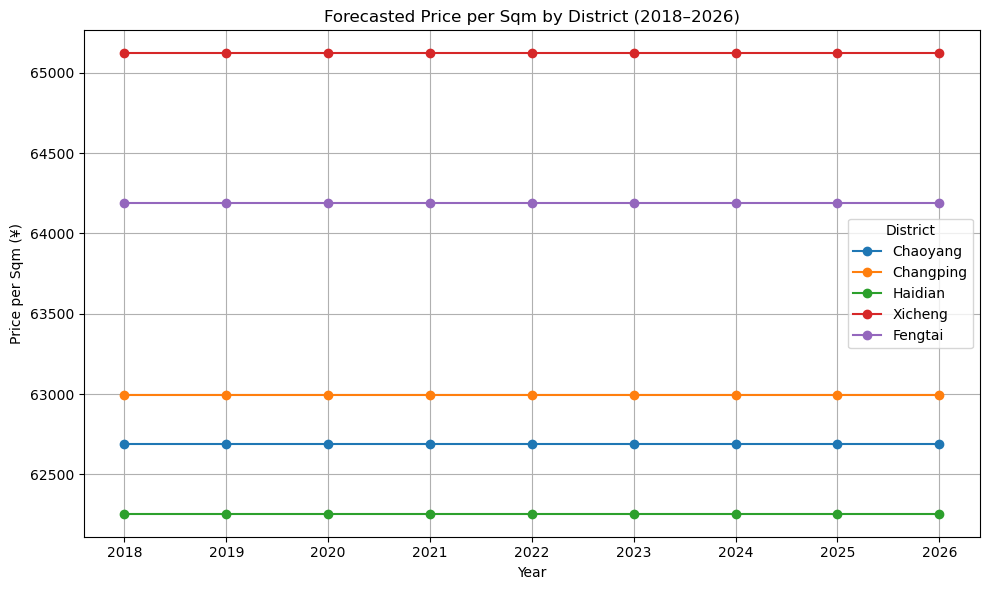

In [14]:
# Step 1: Load and clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# District code-to-name map (from Project.pdf)
district_map = {
    1: "Dongcheng", 2: "Fengtai", 3: "Tongzhou", 4: "Daxing", 5: "Fangshan",
    6: "Changping", 7: "Chaoyang", 8: "Haidian", 9: "Shijingshan", 10: "Xicheng",
    11: "Pinggu", 12: "Mentougou", 13: "Shunyi"
}

# Load data
df = pd.read_excel(
    "NUS Project/BeijingHousingPrices (2011-2017).xlsx",
    nrows=5000,
    usecols=[
        "price", "square", "elevator", "subway", "district", "buildingStructure",
        "renovationCondition", "ladderRatio", "followers", "DOM", "communityAverage",
        "constructionTime", "tradeTime"
    ]
)

# Clean
df = df.dropna()
df = df[df["constructionTime"] != "Î´Öª"]
df["constructionTime"] = pd.to_numeric(df["constructionTime"], errors="coerce")
df = df.dropna(subset=["constructionTime"])
df["tradeTime"] = pd.to_datetime(df["tradeTime"], errors="coerce")
df = df.dropna(subset=["tradeTime"])
df["tradeYear"] = df["tradeTime"].dt.year
df = df[(df["tradeYear"] >= 2011) & (df["tradeYear"] <= 2017)]
df["pricePerSqm"] = df["price"]

# Step 2: Encode categorical features
cat_cols = ["elevator", "subway", "district", "buildingStructure", "renovationCondition"]
df[cat_cols] = df[cat_cols].astype("category")
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 3: Train model
features = ["tradeYear", "square", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"] + \
           [col for col in df_encoded.columns if any(x in col for x in cat_cols)]

X = df_encoded[features]
y = df_encoded["pricePerSqm"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Step 4: Forecast by district with real names
top_districts = df["district"].value_counts().nlargest(5).index.tolist()
future_years = np.arange(2018, 2027)
forecast_rows = []

for district in top_districts:
    district_name = district_map.get(district, f"District {district}")
    for year in future_years:
        row = X_train.median().to_dict()
        row["tradeYear"] = year
        for col in X.columns:
            if col.startswith("district_"):
                row[col] = 1 if col == f"district_{district}" else 0
        row["districtLabel"] = district_name
        forecast_rows.append(row)

forecast_df = pd.DataFrame(forecast_rows)

# Fill missing columns
for col in X.columns:
    if col not in forecast_df.columns:
        forecast_df[col] = 0

# Predict
forecast_df = forecast_df[X.columns.tolist() + ["districtLabel"]]
forecast_df["predictedPricePerSqm"] = model.predict(forecast_df[X.columns])

# Step 5: Plot forecast
plt.figure(figsize=(10, 6))
for label in forecast_df["districtLabel"].unique():
    subset = forecast_df[forecast_df["districtLabel"] == label]
    plt.plot(subset["tradeYear"], subset["predictedPricePerSqm"], marker='o', label=label)

plt.title("Forecasted Price per Sqm by District (2018–2026)")
plt.xlabel("Year")
plt.ylabel("Price per Sqm (¥)")
plt.grid(True)
plt.legend(title="District")
plt.tight_layout()
plt.show()


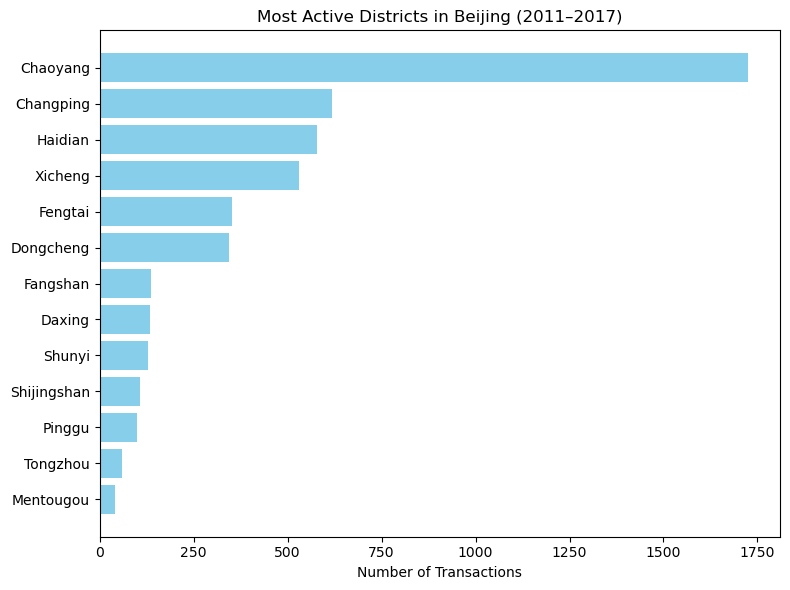

In [17]:
#Districts with the highest number of property transactions during a time period (here: 2011–2017)

import matplotlib.pyplot as plt

# Mapping from district number to name
district_map = {
    1: "Dongcheng", 2: "Fengtai", 3: "Tongzhou", 4: "Daxing", 5: "Fangshan",
    6: "Changping", 7: "Chaoyang", 8: "Haidian", 9: "Shijingshan", 10: "Xicheng",
    11: "Pinggu", 12: "Mentougou", 13: "Shunyi"
}

# Count number of properties per district
district_counts = df["district"].value_counts().sort_values(ascending=True)

# Convert district numbers to names for labeling
district_names = [district_map.get(code, f"District {code}") for code in district_counts.index]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(district_names, district_counts.values, color="skyblue")
plt.xlabel("Number of Transactions")
plt.title("Most Active Districts in Beijing (2011–2017)")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/forecast_growth_2017_2020.png'

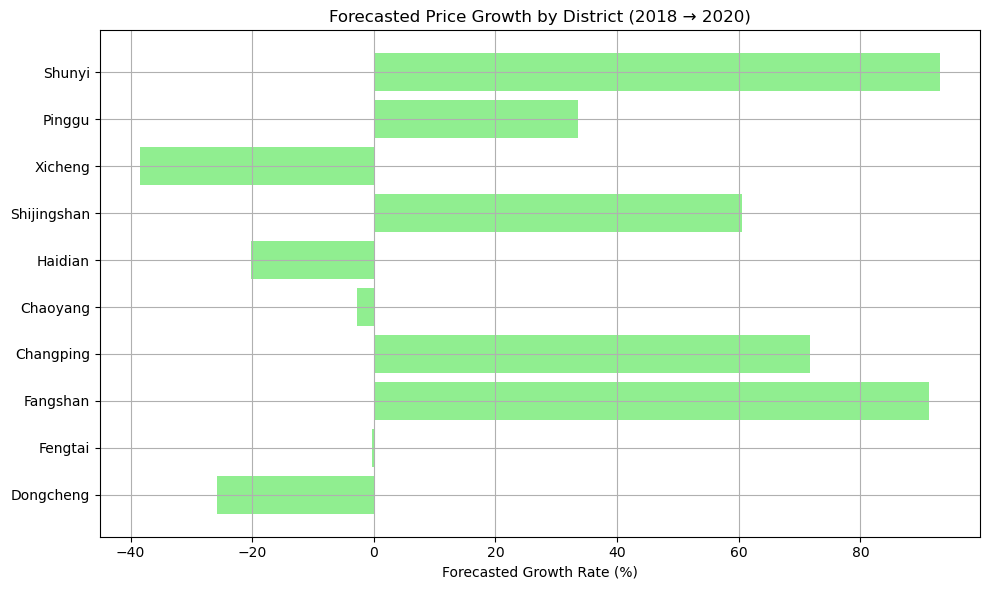

In [26]:
# Re-import everything due to session reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Step 1: Load and clean data
df = pd.read_excel(
    "NUS Project/BeijingHousingPrices (2011-2017).xlsx",
    nrows=5000,
    usecols=[
        "price", "square", "elevator", "subway", "district", "buildingStructure",
        "renovationCondition", "ladderRatio", "followers", "DOM", "communityAverage",
        "constructionTime", "tradeTime"
    ]
)

df = df.dropna()
df = df[df["constructionTime"] != "Î´Öª"]
df["constructionTime"] = pd.to_numeric(df["constructionTime"], errors="coerce")
df = df.dropna(subset=["constructionTime"])
df["tradeTime"] = pd.to_datetime(df["tradeTime"], errors="coerce")
df = df.dropna(subset=["tradeTime"])
df["tradeYear"] = df["tradeTime"].dt.year
df = df[(df["tradeYear"] >= 2011) & (df["tradeYear"] <= 2017)]
df["pricePerSqm"] = df["price"]

# Step 2: Calculate % growth 2016–2017
avg_by_year_district = df.groupby(["district", "tradeYear"])["pricePerSqm"].mean().unstack()
valid_districts = avg_by_year_district.dropna(subset=[2016, 2017])
growth_16_17 = ((valid_districts[2017] - valid_districts[2016]) / valid_districts[2016]) * 100

# Step 3: Train model
cat_cols = ["elevator", "subway", "district", "buildingStructure", "renovationCondition"]
df[cat_cols] = df[cat_cols].astype("category")
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

features = ["tradeYear", "square", "ladderRatio", "followers", "DOM", "communityAverage", "constructionTime"] + \
           [col for col in df_encoded.columns if any(x in col for x in cat_cols)]
X = df_encoded[features]
y = df_encoded["pricePerSqm"]

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Step 4: Forecast 2018–2020 for valid districts
forecast_rows = []
for district in valid_districts.index:
    for year in [2018, 2019, 2020]:
        row = X.median().to_dict()
        row["tradeYear"] = year
        for col in X.columns:
            if col.startswith("district_"):
                row[col] = 1 if col == f"district_{district}" else 0
        row["district"] = district
        row["year"] = year
        forecast_rows.append(row)

forecast_df = pd.DataFrame(forecast_rows)
for col in X.columns:
    if col not in forecast_df.columns:
        forecast_df[col] = 0
forecast_df = forecast_df[X.columns.tolist() + ["district", "year"]]
forecast_df["predicted"] = model.predict(forecast_df[X.columns])

# Step 5: Growth % from 2017 to 2020
forecast_pivot = forecast_df.pivot(index="district", columns="year", values="predicted")
#forecast_growth = ((forecast_pivot[2020] - forecast_pivot[2018]) / forecast_pivot[2018]) * 100
forecast_growth = ((forecast_pivot[2020] - valid_districts[2017]) / valid_districts[2017]) * 100

# Step 6: Bar chart
district_map = {
    1: "Dongcheng", 2: "Fengtai", 3: "Tongzhou", 4: "Daxing", 5: "Fangshan",
    6: "Changping", 7: "Chaoyang", 8: "Haidian", 9: "Shijingshan", 10: "Xicheng",
    11: "Pinggu", 12: "Mentougou", 13: "Shunyi"
}
district_labels = [district_map.get(d, f"District {d}") for d in forecast_growth.index]

plt.figure(figsize=(10, 6))
plt.barh(district_labels, forecast_growth.values, color="lightgreen")
plt.xlabel("Forecasted Growth Rate (%)")
plt.title("Forecasted Price Growth by District (2018 → 2020)")
plt.grid(True)
plt.tight_layout()

growth_bar_path = "/mnt/data/forecast_growth_2017_2020.png"
plt.savefig(growth_bar_path)

growth_bar_path
